## **#Q2 Task1 :  Data Preparation**

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('../data/q2_customers.csv')

# Features
X = df.copy()

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

K-Means clustering is a distance-based algorithm that uses Euclidean distance to assign data points to clusters.
Since the features in the dataset have different scales (e.g., annual spend vs visits), scaling is essential to ensure that no single feature dominates the clustering process.
StandardScaler standardizes the data so that each feature has mean 0 and variance 1, enabling fair contribution of all features.

## **#Q2 Task2 :  Choosing K — Elbow Method**

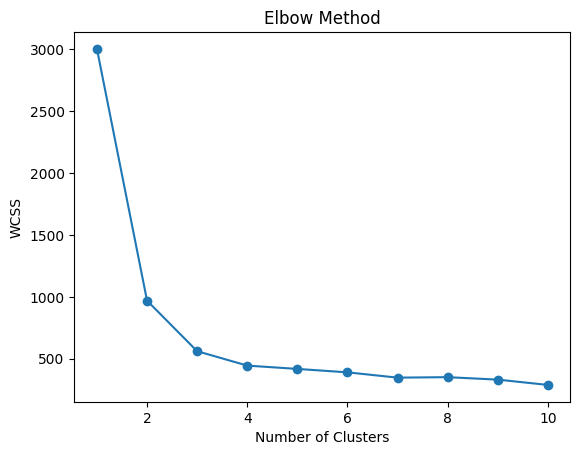

In [2]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

The elbow method plot shows a sharp decrease in WCSS from K = 1 to K = 3, after which the rate of decrease slows down significantly.

This indicates that the most substantial improvement in clustering occurs up to K = 3, and adding more clusters beyond this point results in diminishing returns.

Therefore, K = 3 is selected as the optimal number of clusters, as it provides a good balance between model simplicity and clustering performance.

## **#Q2 Task3 :  K-Means Clustering**

In [4]:
# Fit KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Centroids
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


The K-Means clustering algorithm with K = 3 segments customers into three distinct groups based on their behavior.

Cluster 0 represents young customers (average age ~25) who visit frequently (~14 visits per month) but have low annual spending (~15K) and small basket sizes. These are likely low-value but highly engaged customers, possibly making frequent small purchases.

Cluster 1 consists of older customers (average age ~57) with very high annual spending (~89K) and large basket sizes. However, they visit infrequently (~2–3 visits per month) and have high days since last visit. This group represents high-value but low-frequency customers, likely making bulk or premium purchases.

Cluster 2 represents middle-aged customers (average age ~40) with moderate spending (~43K), moderate visit frequency (~8 visits per month), and medium basket sizes. These customers fall between the other two groups and represent a balanced segment with steady engagement and spending.

Overall, the clustering reveals three distinct customer segments: low-spend frequent shoppers, high-spend infrequent shoppers, and moderate, balanced customers.

## **#Q2 Task4 : Dimensionality Reduction with PCA**

In [5]:
from sklearn.decomposition import PCA

# Apply PCA to scaled data
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [6]:
# Explained variance
explained_var = pca.explained_variance_ratio_

print("Explained Variance Ratio:")
print("PC1:", explained_var[0])
print("PC2:", explained_var[1])

Explained Variance Ratio:
PC1: 0.8356035409841087
PC2: 0.055687636255959766


In [7]:
# Feature loadings
loadings = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=['PC1', 'PC2']
)

print("PCA Loadings:")
loadings

PCA Loadings:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


The first principal component (PC1) captures overall customer value and spending behavior. It has strong positive contributions from features such as annual spend, basket size, number of categories purchased, and age, while visits per month has a negative contribution.

This suggests that PC1 differentiates high-value customers (who spend more and purchase across categories) from lower-value but more frequent shoppers.

The second principal component (PC2) is dominated by days since last visit, which has a very high positive loading. Other features have relatively smaller contributions.

This indicates that PC2 primarily captures customer recency, separating recently active customers from those who have not visited for a long time.

Overall, PC1 represents customer value and spending intensity, while PC2 represents recency of engagement.

## **#Q2 Task5 : Cluster Visualisation**

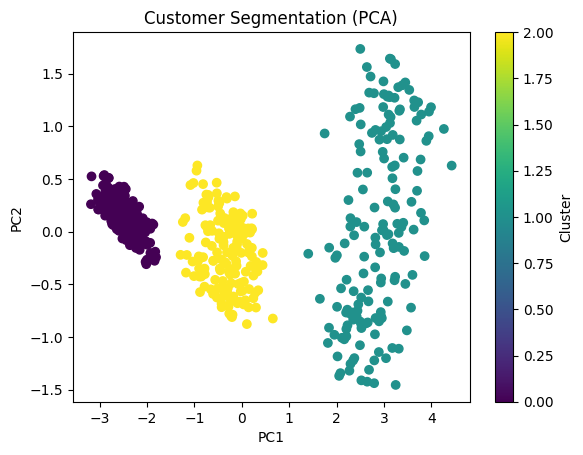

In [8]:
# Visualize clusters in PCA space

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='viridis')
plt.title("Customer Segmentation (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label='Cluster')
plt.show()

The scatter plot of PC1 vs PC2 shows clear separation between the three clusters, indicating that the K-Means clustering has effectively segmented the customers.

The clusters are primarily separated along PC1, which represents customer value and spending behavior, while PC2 further differentiates customers based on recency of visits.

One cluster is positioned on the higher end of PC1, representing high-value customers, while another cluster lies on the lower end, representing low-spending but frequent customers. The third cluster falls in between, indicating moderate customer behavior.

The distinct grouping of points suggests that the segmentation is meaningful and that the underlying customer patterns are well captured by the clustering algorithm.